1. Wczytywanie danych i podział (TARGET_MEAL)...
2. Uczenie WERSJI 2.0 dla POSIŁKÓW (Lasso L1 i Płytsze Drzewa)...
(Info: Waga klasy pozytywnej wynosi: 119.1)
3. Analiza Progu (Cel biznesowy: Precyzja ~15%)...

--- RAPORT MODELU POSIŁKI v2 (Próg: 83.7%) ---
                  precision    recall  f1-score   support

Brak Posiłku (0)       0.99      1.00      1.00    104711
Kupi Posiłek (1)       0.17      0.00      0.00       879

        accuracy                           0.99    105590
       macro avg       0.58      0.50      0.50    105590
    weighted avg       0.98      0.99      0.99    105590


--- EFEKT EKSTREMALNEGO LASSO (L1=50) DLA POSIŁKÓW ---
Liczba kolumn na wejściu: 468
Kolumny użyte (przetrwały): 164
Kolumny wyzerowane (usunięte): 304

--- GENEROWANIE WYKRESÓW WYJAŚNIALNOŚCI (SHAP) ---


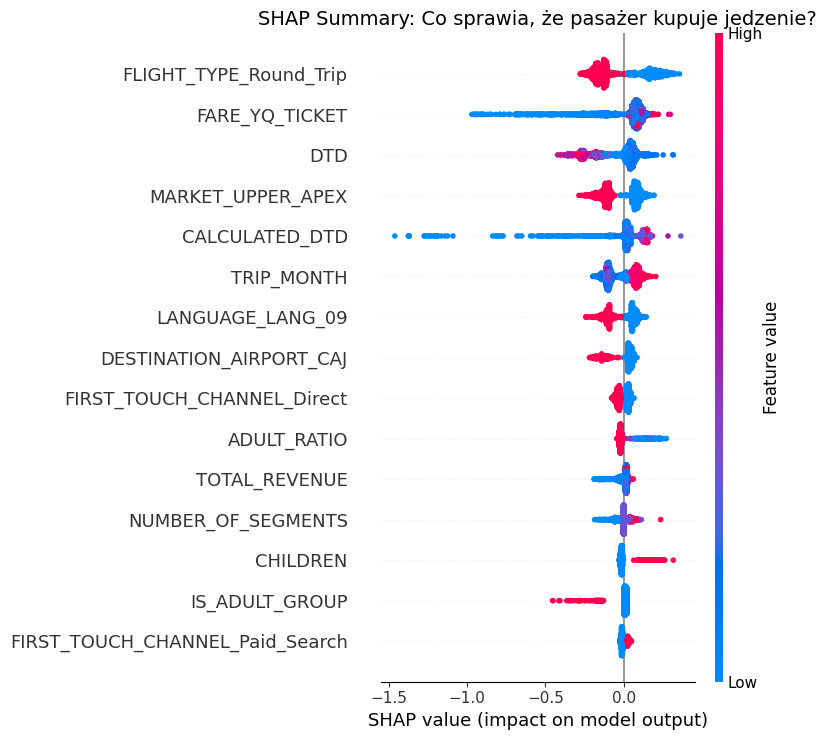

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import shap

warnings.filterwarnings('ignore')

print("1. Wczytywanie danych i podział (TARGET_MEAL)...")
df_final = pd.read_parquet('flight_data_ml_ready.parquet')

# Zmieniamy cel na Posiłek (Meal)
y = df_final['TARGET_MEAL'] 
target_cols = [col for col in df_final.columns if col.startswith('TARGET_')]
X = df_final.drop(columns=target_cols)

# Oczyszczanie nazw kolumn
X = X.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("2. Uczenie WERSJI 2.0 dla POSIŁKÓW (Lasso L1 i Płytsze Drzewa)...")
# Wyrównanie klas
pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)
print(f"(Info: Waga klasy pozytywnej wynosi: {pos_weight:.1f})")

xgb_model_meal_v2 = xgb.XGBClassifier(
    n_estimators=300,          
    learning_rate=0.03,        
    max_depth=4,               
    colsample_bytree=0.8,      
    scale_pos_weight=pos_weight, 
    reg_alpha=50,              # POTĘŻNE LASSO (L1) tnące szum
    reg_lambda=10,             # Ridge (L2) stabilizujące cechy
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb_model_meal_v2.fit(X_train, y_train)

print("3. Analiza Progu (Cel biznesowy: Precyzja ~15%)...")
y_probs_meal_v2 = xgb_model_meal_v2.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_meal_v2)

# Celujemy w 15% precyzji (dobry balans między zasięgiem a brakiem spamu)
target_precision = 0.15
try:
    optimal_idx = np.where(precisions >= target_precision)[0][0]
    optimal_threshold = thresholds[optimal_idx]
except IndexError:
    optimal_idx = np.argmax(precisions)
    optimal_threshold = thresholds[optimal_idx]

y_pred_meal_v2 = (y_probs_meal_v2 >= optimal_threshold).astype(int)

print(f"\n--- RAPORT MODELU POSIŁKI v2 (Próg: {optimal_threshold*100:.1f}%) ---")
print(classification_report(y_test, y_pred_meal_v2, target_names=['Brak Posiłku (0)', 'Kupi Posiłek (1)']))

# --- EFEKT EKSTREMALNEJ REGULARYZACJI ---
print("\n--- EFEKT EKSTREMALNEGO LASSO (L1=50) DLA POSIŁKÓW ---")
used_features = xgb_model_meal_v2.get_booster().get_fscore()
num_used = len(used_features)
num_total = X.shape[1]
print(f"Liczba kolumn na wejściu: {num_total}")
print(f"Kolumny użyte (przetrwały): {num_used}")
print(f"Kolumny wyzerowane (usunięte): {num_total - num_used}")

# --- MAGIA SHAP: Kto kupuje jedzenie w samolocie? ---
print("\n--- GENEROWANIE WYKRESÓW WYJAŚNIALNOŚCI (SHAP) ---")
X_sample = X_test.head(2000)

explainer = shap.TreeExplainer(xgb_model_meal_v2)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(12, 8))
plt.title('SHAP Summary: Co sprawia, że pasażer kupuje jedzenie?', fontsize=14)
shap.summary_plot(shap_values, X_sample, max_display=15, show=False)
plt.tight_layout()
plt.show()

dddd

1. Wczytywanie danych (TARGET_MEAL)...
2. Uczenie WERSJI 3.0 (Luźniejsze Lasso, Głębokie Drzewa)...
3. Analiza Progu (Schodzimy do Precyzji ~5%)...

--- RAPORT MODELU POSIŁKI v3 (Próg: 74.2%) ---
                  precision    recall  f1-score   support

Brak Posiłku (0)       0.99      0.99      0.99    104711
Kupi Posiłek (1)       0.05      0.04      0.05       879

        accuracy                           0.99    105590
       macro avg       0.52      0.52      0.52    105590
    weighted avg       0.98      0.99      0.98    105590


--- EFEKT LUŹNEGO LASSO (L1=5) ---
Liczba kolumn na wejściu: 468
Kolumny użyte (przetrwały): 315
Kolumny wyzerowane (usunięte): 153

--- GENEROWANIE WYKRESÓW WYJAŚNIALNOŚCI (SHAP) ---


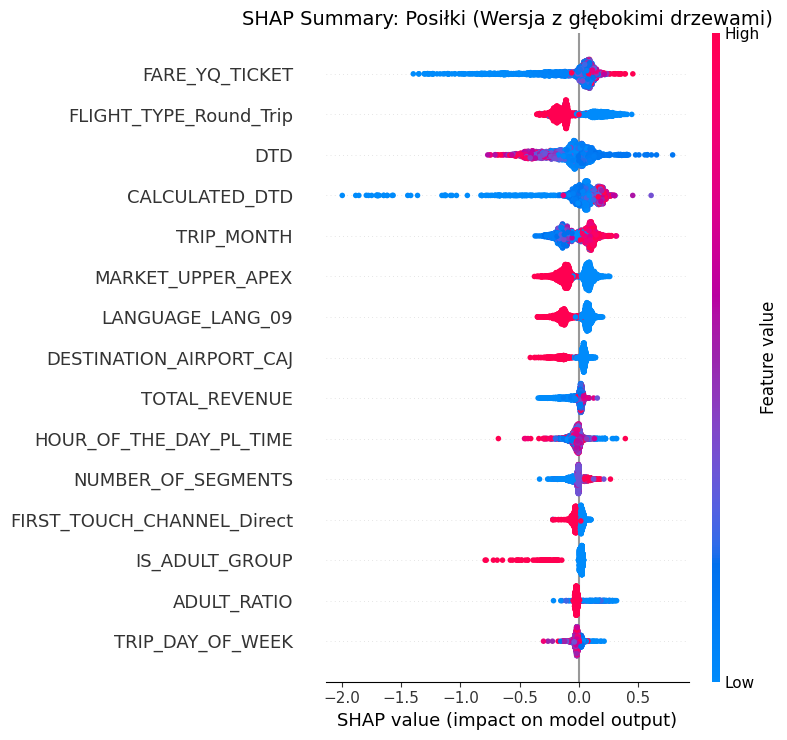

In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import shap

warnings.filterwarnings('ignore')

print("1. Wczytywanie danych (TARGET_MEAL)...")
df_final = pd.read_parquet('flight_data_ml_ready.parquet')

y = df_final['TARGET_MEAL'] 
target_cols = [col for col in df_final.columns if col.startswith('TARGET_')]
X = df_final.drop(columns=target_cols)

X = X.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("2. Uczenie WERSJI 3.0 (Luźniejsze Lasso, Głębokie Drzewa)...")
pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

xgb_model_meal_v3 = xgb.XGBClassifier(
    n_estimators=300,          
    learning_rate=0.05,        # Zwiększamy szybkość uczenia
    max_depth=7,               # GŁĘBSZE DRZEWA - szukanie skomplikowanych wzorców
    colsample_bytree=0.8,      
    scale_pos_weight=pos_weight, 
    reg_alpha=5,               # LŻEJSZE LASSO - pozwalamy przetrwać większej liczbie kolumn
    reg_lambda=10,             
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb_model_meal_v3.fit(X_train, y_train)

print("3. Analiza Progu (Schodzimy do Precyzji ~5%)...")
y_probs_meal_v3 = xgb_model_meal_v3.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_meal_v3)

# Bardzo niski próg precyzji - akceptujemy dużo spamu, byle podnieść Recall
target_precision = 0.05
try:
    optimal_idx = np.where(precisions >= target_precision)[0][0]
    optimal_threshold = thresholds[optimal_idx]
except IndexError:
    optimal_idx = np.argmax(precisions)
    optimal_threshold = thresholds[optimal_idx]

y_pred_meal_v3 = (y_probs_meal_v3 >= optimal_threshold).astype(int)

print(f"\n--- RAPORT MODELU POSIŁKI v3 (Próg: {optimal_threshold*100:.1f}%) ---")
print(classification_report(y_test, y_pred_meal_v3, target_names=['Brak Posiłku (0)', 'Kupi Posiłek (1)']))

# --- SPRAWDZAMY, ILE KOLUMN PRZETRWAŁO ---
print("\n--- EFEKT LUŹNEGO LASSO (L1=5) ---")
used_features = xgb_model_meal_v3.get_booster().get_fscore()
num_used = len(used_features)
num_total = X.shape[1]
print(f"Liczba kolumn na wejściu: {num_total}")
print(f"Kolumny użyte (przetrwały): {num_used}")
print(f"Kolumny wyzerowane (usunięte): {num_total - num_used}")

# --- WYKRES SHAP ---
print("\n--- GENEROWANIE WYKRESÓW WYJAŚNIALNOŚCI (SHAP) ---")
X_sample = X_test.head(2000)
explainer = shap.TreeExplainer(xgb_model_meal_v3)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(12, 8))
plt.title('SHAP Summary: Posiłki (Wersja z głębokimi drzewami)', fontsize=14)
shap.summary_plot(shap_values, X_sample, max_display=15, show=False)
plt.tight_layout()
plt.show()